In [2]:
import pandas as pd


df = pd.read_excel("/content/Sales Data_PDA_4052 (1).xlsx")

print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset info:")
df.info()

print("\nMissing values in each column:")
print(df.isnull().sum())



Shape of dataset: (1002, 7)

Column names:
['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6']

First 5 rows:


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,order_id,customer_id,sales_person,priority,ship_mode,date,value_£
1,8999,C406,Kelly,High,Plane,2020-06-12 00:00:00,1553.44
2,47872,C100,Kelly,Critical,Plane,2020-06-12 00:00:00,315.4
3,29988,C006,Kelly,High,Lorry,2020-06-12 00:00:00,5075.89
4,37348,C492,Kelly,High,Plane,2020-06-13 00:00:00,520.67



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  1002 non-null   object
 1   Unnamed: 1  1002 non-null   object
 2   Unnamed: 2  1002 non-null   object
 3   Unnamed: 3  1002 non-null   object
 4   Unnamed: 4  1002 non-null   object
 5   Unnamed: 5  1002 non-null   object
 6   Unnamed: 6  1002 non-null   object
dtypes: object(7)
memory usage: 54.9+ KB

Missing values in each column:
Unnamed: 0    0
Unnamed: 1    0
Unnamed: 2    0
Unnamed: 3    0
Unnamed: 4    0
Unnamed: 5    0
Unnamed: 6    0
dtype: int64


In [3]:
# Set first row as header
df.columns = df.iloc[0]

# Remove the first row (since it's now header)
df = df[1:]

# Reset index
df.reset_index(drop=True, inplace=True)

# Show result
print("Fixed columns:")
print(df.columns)

print("\nFirst 5 rows after fixing:")
display(df.head())

Fixed columns:
Index(['order_id', 'customer_id', 'sales_person', 'priority', 'ship_mode',
       'date', 'value_£'],
      dtype='object', name=0)

First 5 rows after fixing:


,order_id,customer_id,sales_person,priority,ship_mode,date,value_£
0,8999,C406,Kelly,High,Plane,2020-06-12 00:00:00,1553.44
1,47872,C100,Kelly,Critical,Plane,2020-06-12 00:00:00,315.4
2,29988,C006,Kelly,High,Lorry,2020-06-12 00:00:00,5075.89
3,37348,C492,Kelly,High,Plane,2020-06-13 00:00:00,520.67
4,28001,C231,Kelly,Critical,Plane,2020-06-14 00:00:00,8431.37


In [4]:
# Convert date column
df['date'] = pd.to_datetime(df['date'])

# Convert value column to numeric
df['value_£'] = pd.to_numeric(df['value_£'])

# Check updated data types
print("Updated data types:")
print(df.dtypes)

print("\nDataset info after conversion:")
df.info()

Updated data types:
0
order_id                object
customer_id             object
sales_person            object
priority                object
ship_mode               object
date            datetime64[ns]
value_£                float64
dtype: object

Dataset info after conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      1001 non-null   object        
 1   customer_id   1001 non-null   object        
 2   sales_person  1001 non-null   object        
 3   priority      1001 non-null   object        
 4   ship_mode     1001 non-null   object        
 5   date          1001 non-null   datetime64[ns]
 6   value_£       1001 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(5)
memory usage: 54.9+ KB


In [5]:
# Check duplicate rows
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

# Remove duplicates if any
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Number of duplicate rows: 0
Shape after removing duplicates: (1001, 7)


In [6]:
# Descriptive statistics for numerical column
print("Statistical Summary:")
display(df['value_£'].describe())

Statistical Summary:


,value_£
count,1001.000000
mean,1778.402248
std,3457.457206
min,2.450000
25%,134.400000
50%,417.580000
75%,1816.930000
max,27448.240000


SALES BY SALESPERSON

Total Sales by Salesperson:


,value_£
sales_person,
Pryia,672228.97
Kelly,558659.62
Peter,549292.06


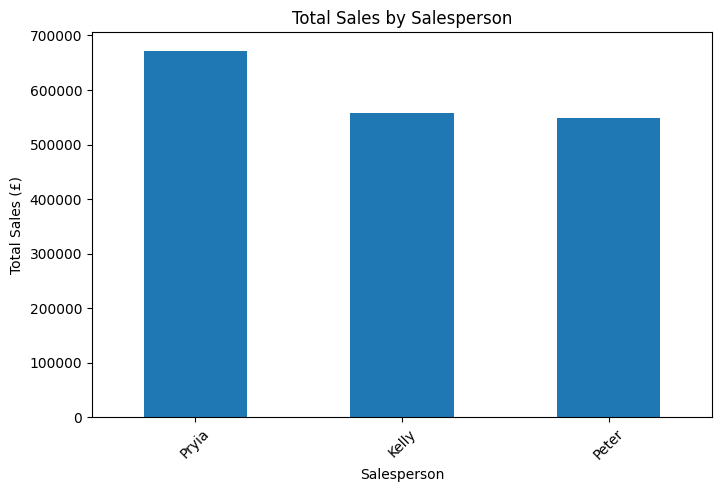

In [7]:
# Total sales per salesperson
sales_by_person = df.groupby('sales_person')['value_£'].sum().sort_values(ascending=False)

print("Total Sales by Salesperson:")
display(sales_by_person)

# Plot
import matplotlib.pyplot as plt

sales_by_person.plot(kind='bar', figsize=(8,5))
plt.title("Total Sales by Salesperson")
plt.xlabel("Salesperson")
plt.ylabel("Total Sales (£)")
plt.xticks(rotation=45)
plt.show()

PRIORITY vs SALES

In [8]:
# Average sales by priority
priority_sales = df.groupby('priority')['value_£'].mean().sort_values(ascending=False)

print("Average Sales by Priority:")
display(priority_sales)

Average Sales by Priority:


,value_£
priority,
High,1946.650000
Medium,1931.797485
Critical,1826.481131
Not Specified,1747.003474
Low,1462.679050


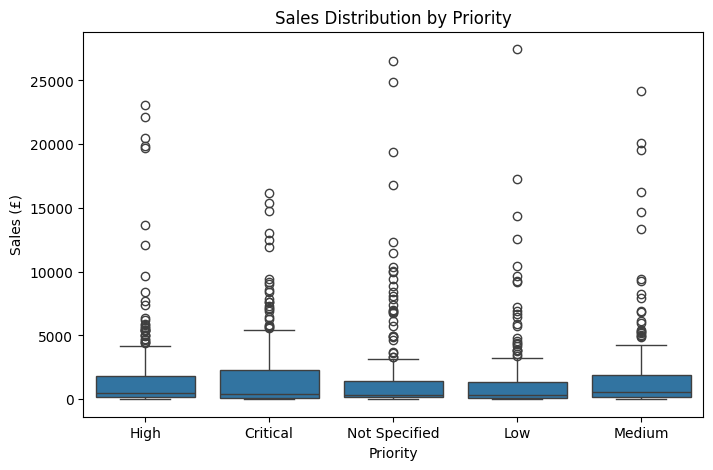

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x='priority', y='value_£', data=df)
plt.title("Sales Distribution by Priority")
plt.xlabel("Priority")
plt.ylabel("Sales (£)")
plt.show()

CORRELATION CHECK

In [10]:
# Correlation matrix
corr = df[['value_£']].corr()

print("Correlation Matrix:")
display(corr)

Correlation Matrix:


,value_£
0,
value_£,1.0


In [11]:
# Convert priority to numeric
priority_mapping = {
    'Low': 1,
    'Not Specified': 2,
    'Medium': 3,
    'High': 4,
    'Critical': 5
}

df['priority_encoded'] = df['priority'].map(priority_mapping)

# Correlation
corr = df[['value_£', 'priority_encoded']].corr()

print("Correlation between Priority and Sales:")
display(corr)

Correlation between Priority and Sales:


,value_£,priority_encoded
0,,
value_£,1.000000,0.037432
priority_encoded,0.037432,1.000000


TIME ANALYSIS

Monthly Sales:


,value_£
month,
2020-06,144279.72
2020-07,378143.61
2020-08,332645.49
2020-09,324590.99
2020-10,355178.46
2020-11,245342.38


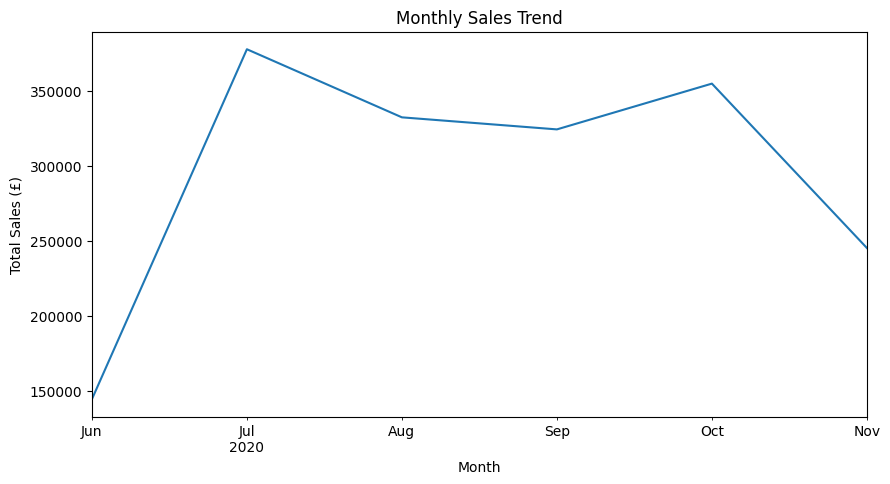

In [12]:
# Extract month
df['month'] = df['date'].dt.to_period('M')

# Monthly sales
monthly_sales = df.groupby('month')['value_£'].sum()

print("Monthly Sales:")
display(monthly_sales)

# Plot
import matplotlib.pyplot as plt

monthly_sales.plot(figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales (£)")
plt.xticks(rotation=45)
plt.show()